In [1]:
import os
import sys
from pathlib import Path

ROOT = Path(os.getcwd()).resolve().parents[1]  # bart-playground root
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

notebook = "real4_Concrete"

In [2]:
import numpy as np
from ucimlrepo import fetch_ucirepo

# Load Concrete Compressive Strength dataset
concrete = fetch_ucirepo(id=165)
X = concrete.data.features.values.astype(float)
y = np.asarray(concrete.data.targets).reshape(-1)

X.shape, y.shape

((1030, 8), (1030,))

In [ ]:
import sys
from pathlib import Path

# Load the experiment runner from diagnosis/1M-iters/experiment.py
EXPERIMENT_DIR = ROOT / "diagnosis" / "1M-iters"
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.append(str(EXPERIMENT_DIR))
from experiment import run_parallel_experiments

# User-specified settings
ndpost = 10000000 # 10M
store_every = 1000
nskip = 0

results = run_parallel_experiments(
    X,
    y,
    ndpost=ndpost,
    nskip=nskip,
    n_trees=100,
    notebook=notebook,
    n_runs=2,
    n_chains=4,
    n_jobs=-2,
    store_every=store_every,
    store_dir="store",
    progress_print=True,
 )

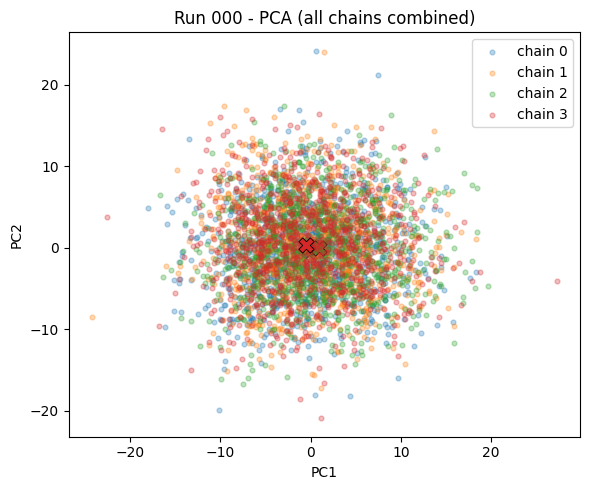

Run 000 centroids (PC1, PC2):
  chain 0: (-0.1782, -0.3951)
  chain 1: (-0.2416, 0.1000)
  chain 2: (0.9614, -0.0572)
  chain 3: (-0.5416, 0.3523)


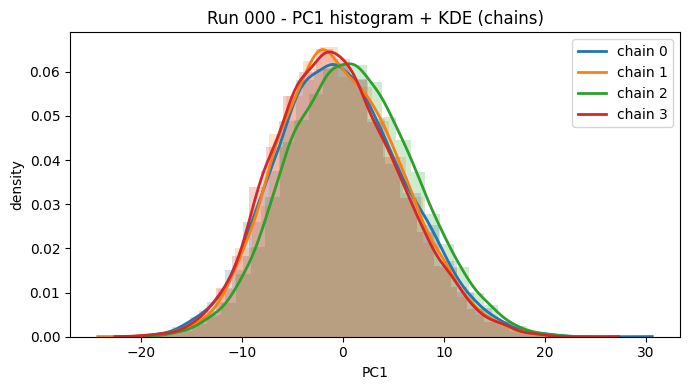

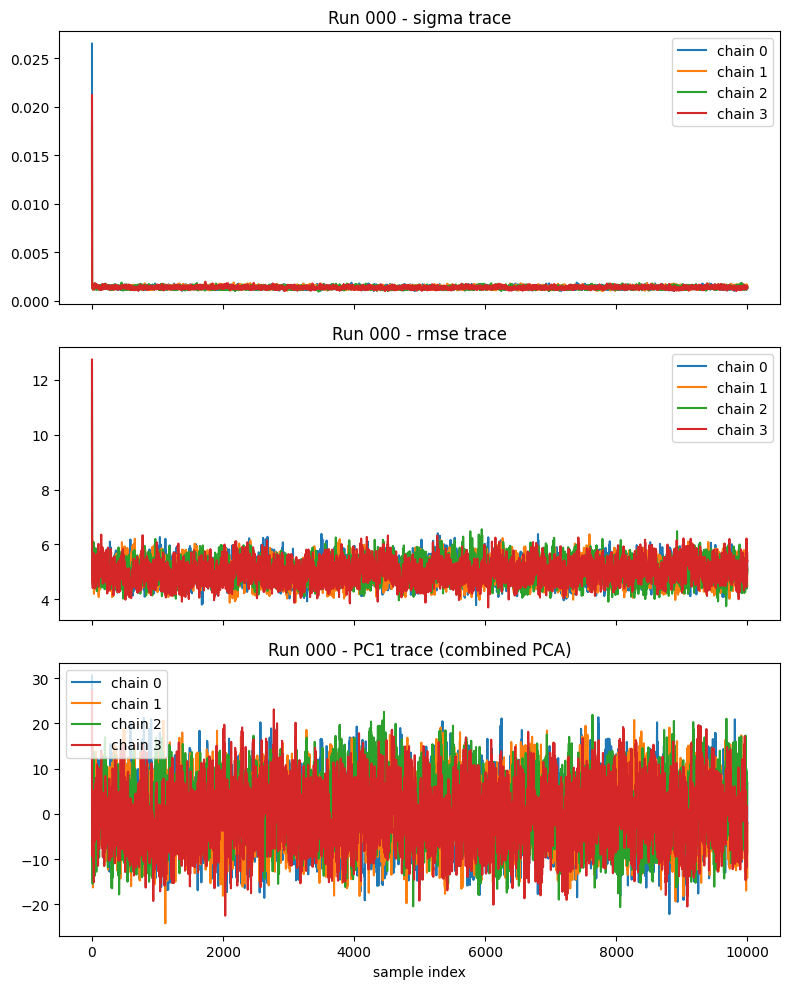

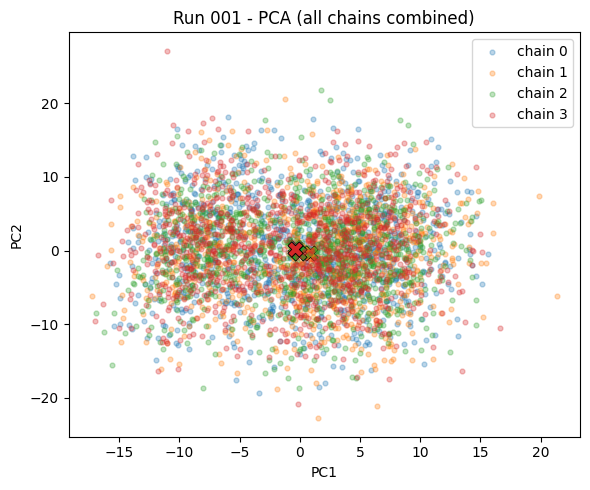

Run 001 centroids (PC1, PC2):
  chain 0: (-0.3986, 0.4868)
  chain 1: (0.8901, -0.3831)
  chain 2: (-0.0680, -0.3128)
  chain 3: (-0.4236, 0.2092)


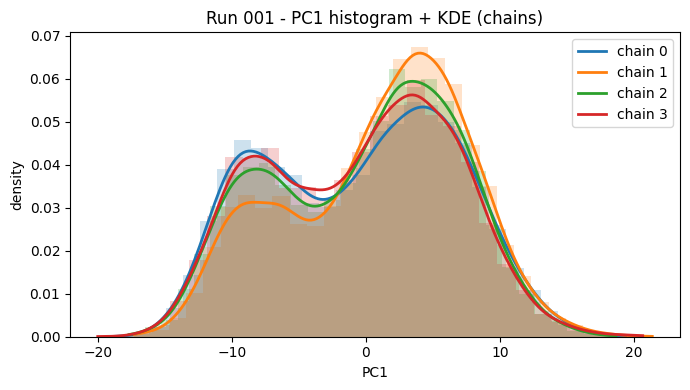

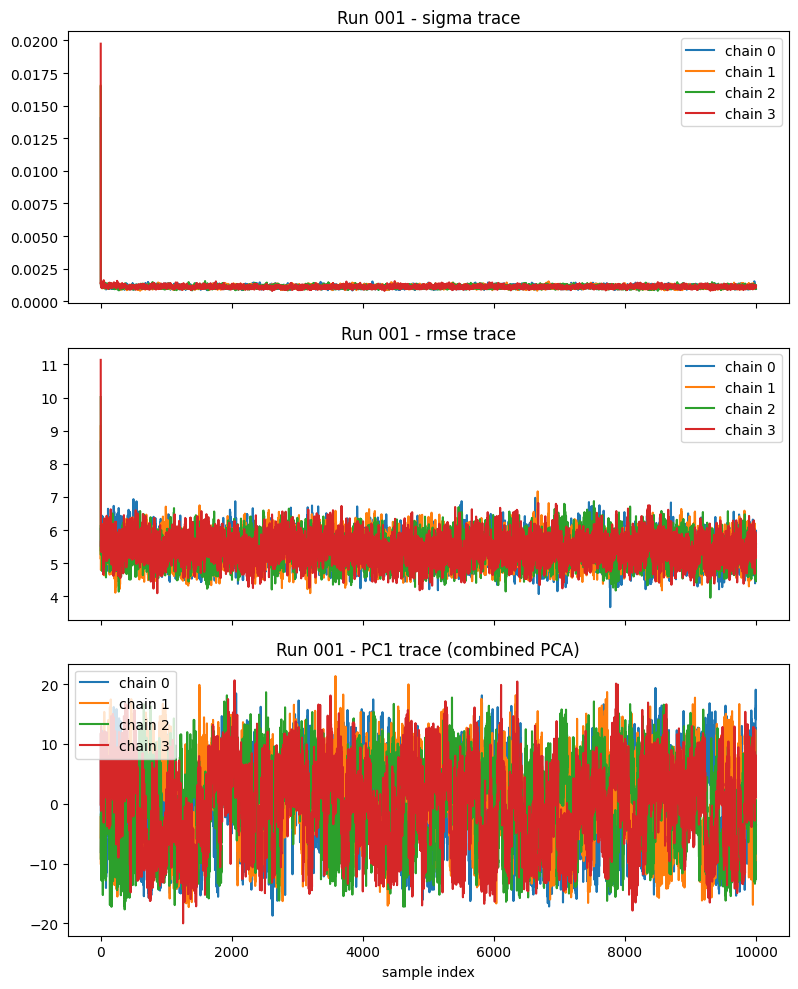

In [3]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA

STORE_DIR = ROOT / "diagnosis" / "1M-iters" / "store"
RUN_IDS = [0, 1]  # update if you have more runs
MODEL = "default"
NOTEBOOK_TAG = notebook
DOWNSAMPLE_PER_CHAIN = 1000  # number of points per chain in PCA scatter
SCATTER_ALPHA = 0.3
CHAIN_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # high-contrast

def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape

def _plot_pc1_hist_kde(pc1_groups, labels, colors, title):
    plt.figure(figsize=(7, 4))
    for data, label, color in zip(pc1_groups, labels, colors):
        data = np.asarray(data)
        plt.hist(
            data,
            bins=30,
            density=True,
            alpha=0.22,
            color=color,
            label="_nolegend_",
        )
        kde = gaussian_kde(data)
        xs = np.linspace(np.min(data), np.max(data), 200)
        plt.plot(xs, kde(xs), color=color, linewidth=2, label=label)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()

for run_id in RUN_IDS:
    preds_path = STORE_DIR / "preds" / f"{NOTEBOOK_TAG}__run{run_id:03d}__{MODEL}__preds.csv"
    sigmas_path = STORE_DIR / "sigmas" / f"{NOTEBOOK_TAG}__run{run_id:03d}__{MODEL}__sigmas.csv"
    rmses_path = STORE_DIR / "rmses" / f"{NOTEBOOK_TAG}__run{run_id:03d}__{MODEL}__rmses.csv"

    preds_raw, preds_shape = _load_with_shape(preds_path)
    sigmas_raw, sigmas_shape = _load_with_shape(sigmas_path)
    rmses_raw, rmses_shape = _load_with_shape(rmses_path)

    preds = preds_raw.reshape(preds_shape)
    sigmas = sigmas_raw.reshape(sigmas_shape)
    rmses = rmses_raw.reshape(rmses_shape)

    n_chains = preds.shape[0]
    n_samples = preds.shape[2]
    colors = [CHAIN_COLORS[i % len(CHAIN_COLORS)] for i in range(n_chains)]

    # Fit PCA once per run using all chains together (all samples as rows).
    sample_vectors = preds.transpose(0, 2, 1).reshape(n_chains * n_samples, -1)
    pca = PCA(n_components=2, random_state=0)
    sample_coords = pca.fit_transform(sample_vectors)
    pc1 = sample_coords[:, 0].reshape(n_chains, n_samples)
    pc2 = sample_coords[:, 1].reshape(n_chains, n_samples)

    rng = np.random.default_rng(0)
    plt.figure(figsize=(6, 5))
    for c in range(n_chains):
        if DOWNSAMPLE_PER_CHAIN is not None and DOWNSAMPLE_PER_CHAIN < n_samples:
            idx = rng.choice(n_samples, size=DOWNSAMPLE_PER_CHAIN, replace=False)
        else:
            idx = np.arange(n_samples)
        plt.scatter(
            pc1[c][idx],
            pc2[c][idx],
            color=colors[c],
            s=12,
            alpha=SCATTER_ALPHA,
            label=f"chain {c}",
        )
        centroid_x = np.mean(pc1[c])
        centroid_y = np.mean(pc2[c])
        plt.scatter(
            centroid_x,
            centroid_y,
            color=colors[c],
            s=120,
            marker="X",
            edgecolor="black",
            linewidth=0.6,
        )
    plt.title(f"Run {run_id:03d} - PCA (all chains combined)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Run {run_id:03d} centroids (PC1, PC2):")
    for c in range(n_chains):
        centroid_x = float(np.mean(pc1[c]))
        centroid_y = float(np.mean(pc2[c]))
        print(f"  chain {c}: ({centroid_x:.4f}, {centroid_y:.4f})")

    _plot_pc1_hist_kde(
        pc1_groups=[pc1[c] for c in range(n_chains)],
        labels=[f"chain {c}" for c in range(n_chains)],
        colors=colors,
        title=f"Run {run_id:03d} - PC1 histogram + KDE (chains)",
    )

    # Trace plots: sigmas, rmses, pc1 (PC1 from the combined PCA above)
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
    for c in range(n_chains):
        axes[0].plot(sigmas[c], color=colors[c], label=f"chain {c}")
        axes[1].plot(rmses[c], color=colors[c], label=f"chain {c}")
        axes[2].plot(pc1[c], color=colors[c], label=f"chain {c}")
    axes[0].set_title(f"Run {run_id:03d} - sigma trace")
    axes[1].set_title(f"Run {run_id:03d} - rmse trace")
    axes[2].set_title(f"Run {run_id:03d} - PC1 trace (combined PCA)")
    axes[2].set_xlabel("sample index")
    for ax in axes:
        ax.legend()
    plt.tight_layout()
    plt.show()

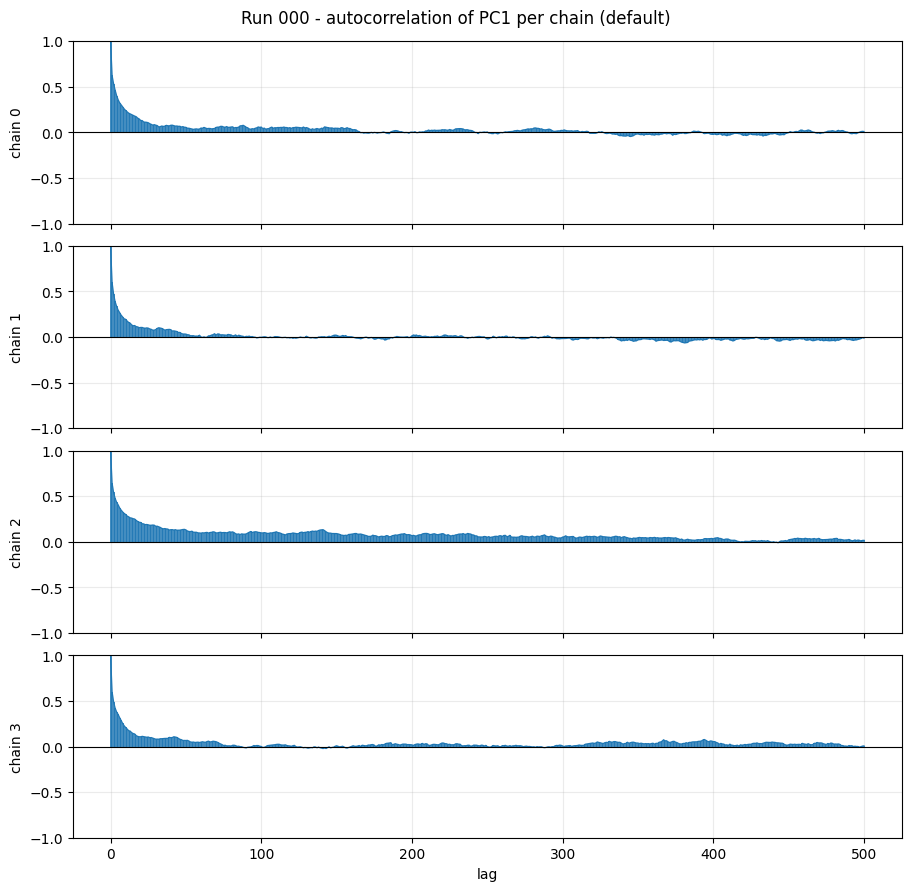

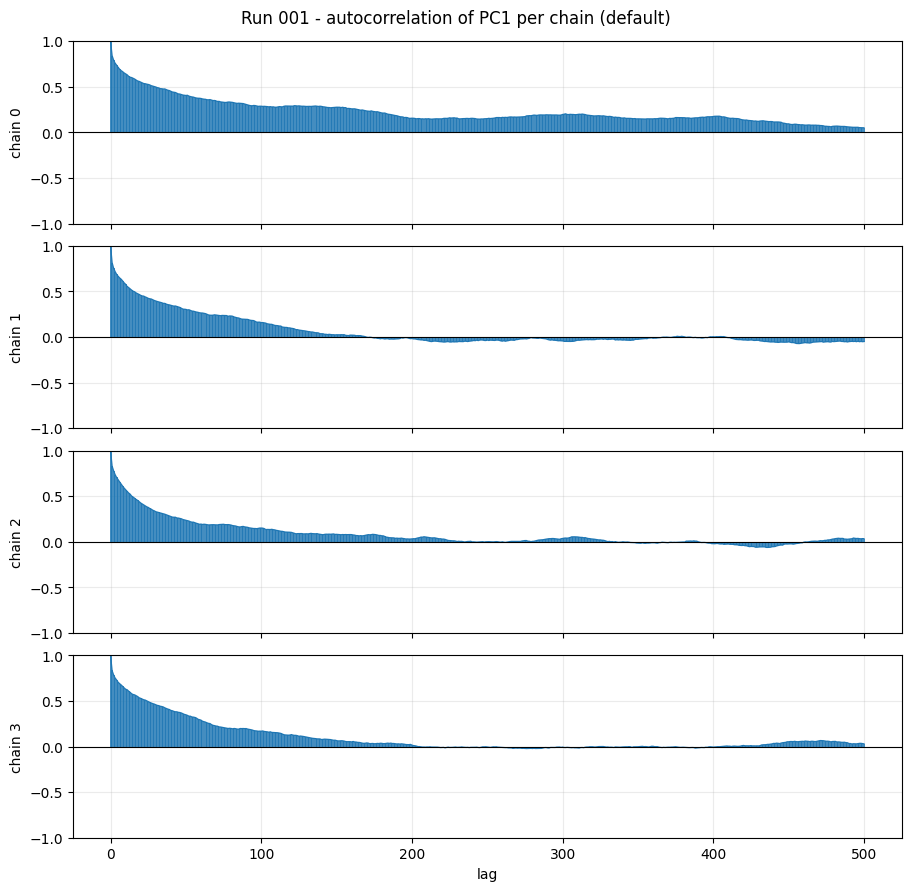

In [4]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

STORE_DIR = ROOT / "diagnosis" / "1M-iters" / "store"
MODEL = "default"
NOTEBOOK_TAG = notebook
MAX_LAG = 500  # set None to use n_samples - 1


def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape


def _available_run_ids(preds_dir: Path, tag: str, method: str):
    run_ids = []
    for path in preds_dir.glob(f"{tag}__run*__{method}__preds.csv"):
        parts = path.name.split("__run")
        if len(parts) < 2:
            continue
        run_fragment = parts[1].split("__", 1)[0]
        try:
            run_ids.append(int(run_fragment))
        except ValueError:
            continue
    return sorted(set(run_ids))


def _acf_1d(x: np.ndarray, max_lag: int):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    n = x.size
    if n < 2:
        return np.array([1.0])
    denom = np.dot(x, x)
    if denom == 0:
        return np.full(max_lag + 1, np.nan)
    corr = np.correlate(x, x, mode="full")[n - 1 : n + max_lag]
    return corr / denom


preds_dir = STORE_DIR / "preds"
run_ids = _available_run_ids(preds_dir, NOTEBOOK_TAG, MODEL)
if not run_ids:
    raise FileNotFoundError(
        f"No prediction files found in {preds_dir} for tag='{NOTEBOOK_TAG}' and model='{MODEL}'."
    )

for run_id in run_ids:
    preds_path = preds_dir / f"{NOTEBOOK_TAG}__run{run_id:03d}__{MODEL}__preds.csv"
    preds_raw, preds_shape = _load_with_shape(preds_path)
    preds = preds_raw.reshape(preds_shape)  # (n_chains, n_points, n_samples)

    n_chains = preds.shape[0]
    n_samples = preds.shape[2]

    # PCA fit per run using all chains and samples, then extract per-chain PC1 traces.
    sample_vectors = preds.transpose(0, 2, 1).reshape(n_chains * n_samples, -1)
    pca = PCA(n_components=1, random_state=0)
    pc1 = pca.fit_transform(sample_vectors).reshape(n_chains, n_samples)

    max_lag = (n_samples - 1) if MAX_LAG is None else min(MAX_LAG, n_samples - 1)
    lags = np.arange(max_lag + 1)

    fig, axes = plt.subplots(
        n_chains,
        1,
        figsize=(9, 2.2 * n_chains),
        sharex=True,
        constrained_layout=True,
    )
    if n_chains == 1:
        axes = [axes]

    for chain_id, ax in enumerate(axes):
        acf_vals = _acf_1d(pc1[chain_id], max_lag)
        ax.vlines(lags, 0, acf_vals, color="#1f77b4", linewidth=1.2)
        ax.plot(lags, acf_vals, color="#1f77b4", linewidth=0.9)
        ax.axhline(0.0, color="black", linewidth=0.8)
        ax.set_ylabel(f"chain {chain_id}")
        ax.set_ylim(-1.0, 1.0)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel("lag")
    fig.suptitle(f"Run {run_id:03d} - autocorrelation of PC1 per chain ({MODEL})")
    plt.show()

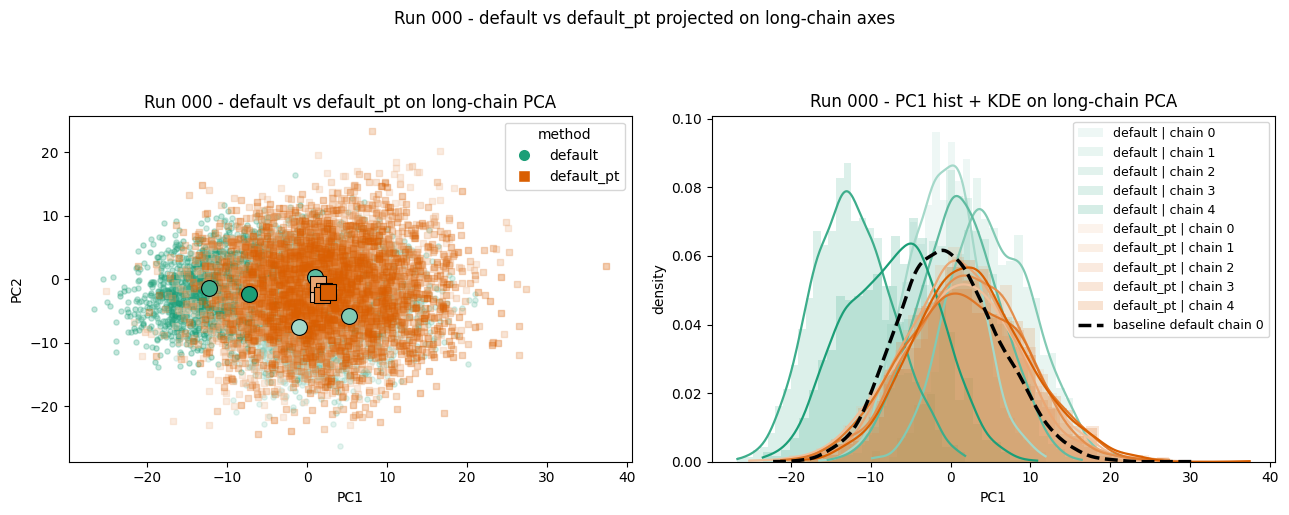

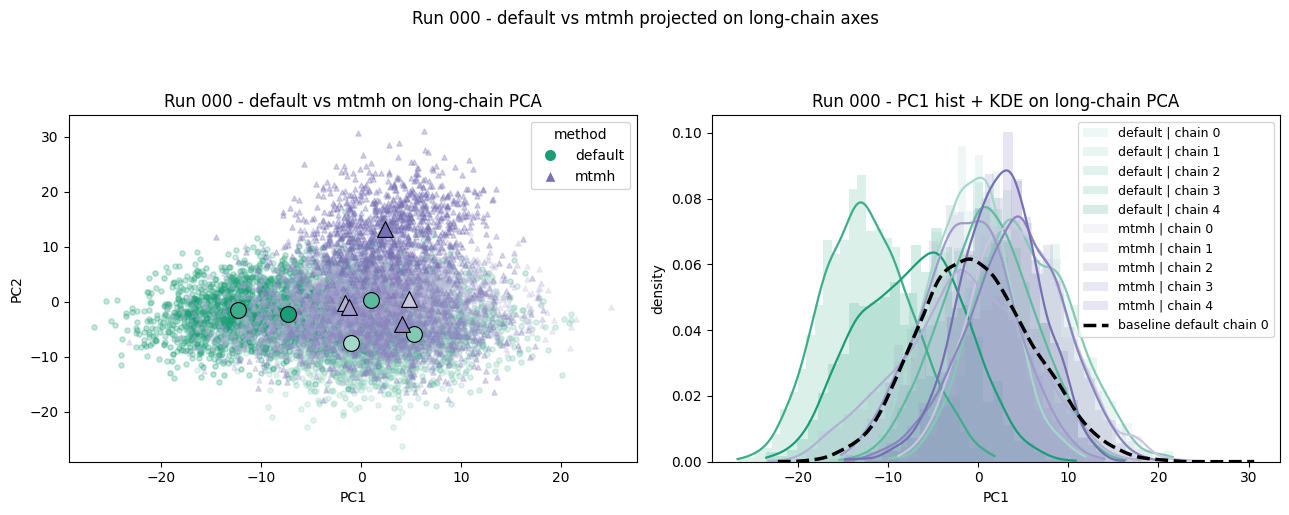

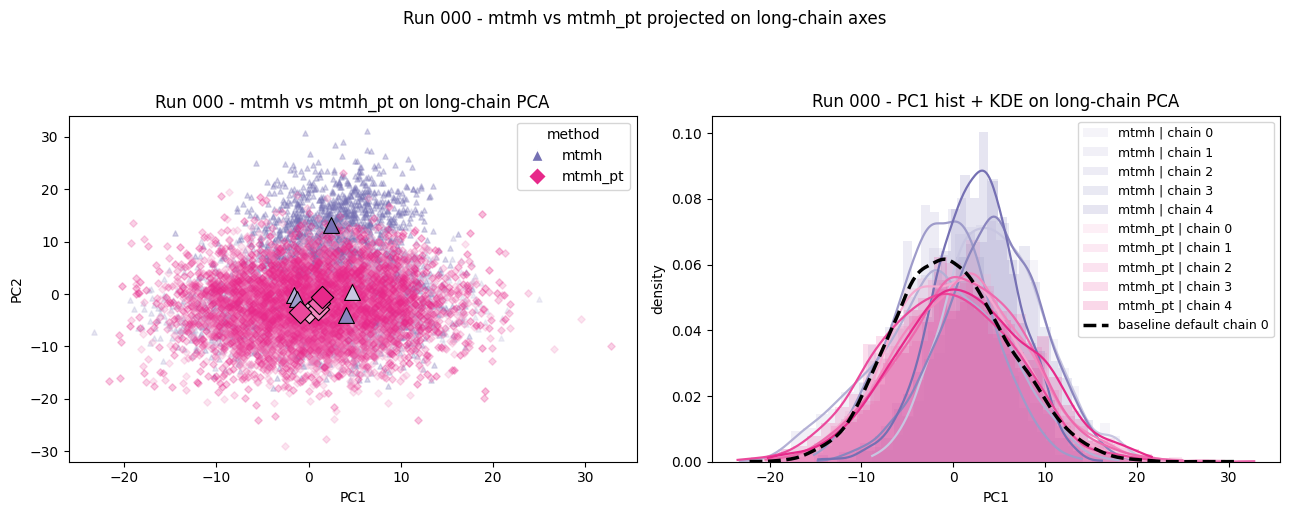

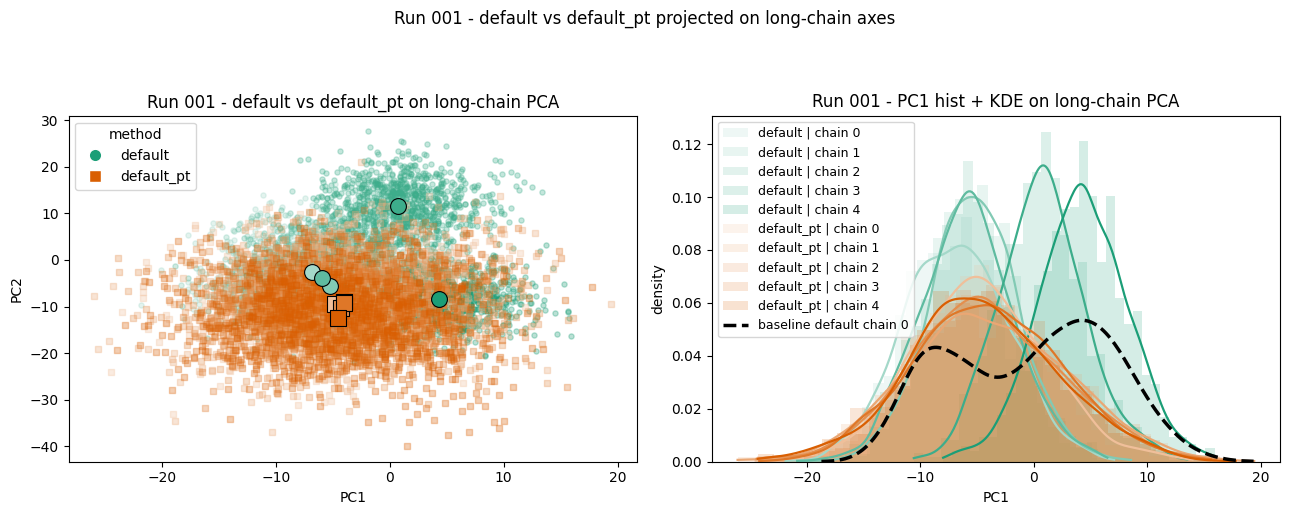

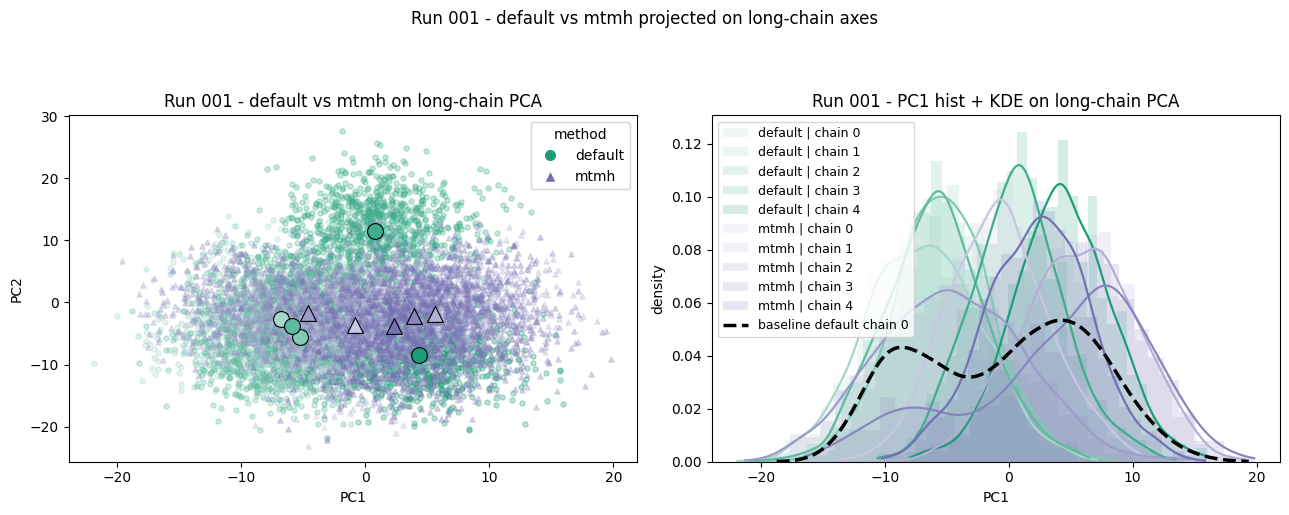

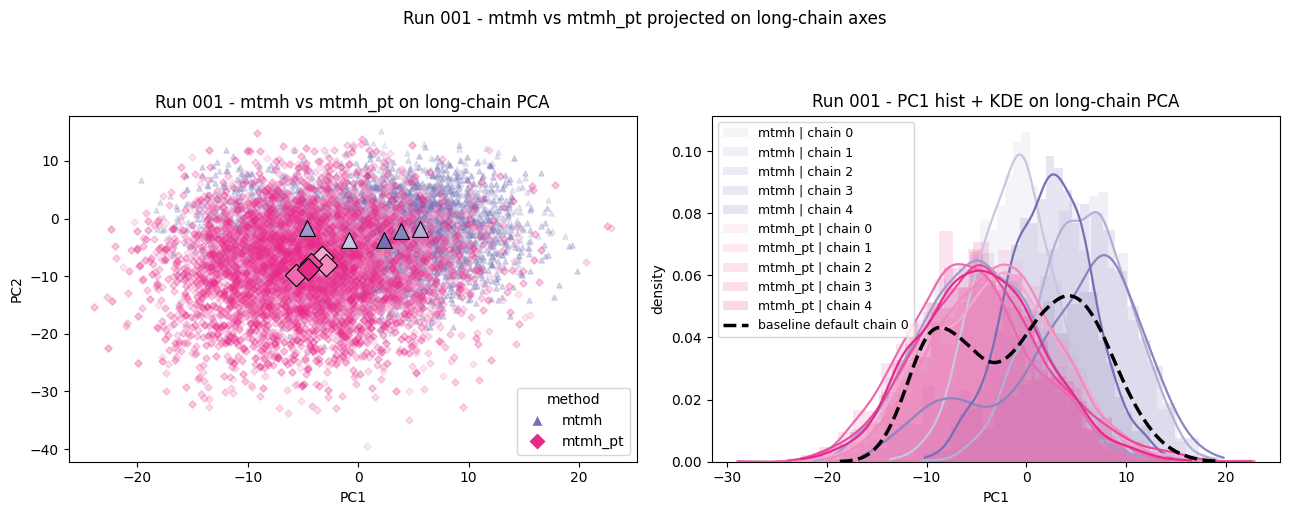

In [5]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

BASE_STORE = ROOT / "diagnosis" / "1M-iters" / "store"
PT_STORE = ROOT / "diagnosis" / "pt+mtmh_2000" / "store"
BASE_NOTEBOOK_TAG = notebook
PT_NOTEBOOK_TAG = f"{notebook}_pt_mtmh"
RUN_IDS = [0, 1]  # update if you have more runs
PAIRWISE_COMPARISONS = [
    ("default", "default_pt"),
    ("default", "mtmh"),
    ("mtmh", "mtmh_pt"),
]
BASELINE_METHOD = "default"
BURN_IN = 500
DOWNSAMPLE_PER_CHAIN = 1000
SCATTER_ALPHA = 0.30
METHOD_MARKERS = {
    "default": "o",
    "default_pt": "s",
    "mtmh": "^",
    "mtmh_pt": "D",
}
METHOD_COLORS = {
    "default": "#1b9e77",
    "default_pt": "#d95f02",
    "mtmh": "#7570b3",
    "mtmh_pt": "#e7298a",
}

def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape

def _load_pred_chains(store_root: Path, notebook_tag: str, run_id: int, method: str):
    preds_path = store_root / "preds" / f"{notebook_tag}__run{run_id:03d}__{method}__preds.csv"
    preds_raw, preds_shape = _load_with_shape(preds_path)
    preds = preds_raw.reshape(preds_shape)
    chains = []
    for chain_id in range(preds.shape[0]):
        chain_preds = preds[chain_id]
        if BURN_IN > 0:
            chain_preds = chain_preds[:, BURN_IN:]
        chains.append(chain_preds)
    return preds, chains

def _fit_long_chain_pca(run_id: int):
    base_preds, _ = _load_pred_chains(BASE_STORE, BASE_NOTEBOOK_TAG, run_id, BASELINE_METHOD)
    base_vectors = base_preds.transpose(0, 2, 1).reshape(base_preds.shape[0] * base_preds.shape[2], -1)
    pca = PCA(n_components=2, random_state=0)
    pca.fit(base_vectors)
    baseline_pc1 = pca.transform(base_preds[0].T)[:, 0]
    return pca, baseline_pc1

def _fit_pair_joint_pca(run_id: int, method_a: str, method_b: str):
    method_a_preds, method_a_chains = _load_pred_chains(PT_STORE, PT_NOTEBOOK_TAG, run_id, method_a)
    method_b_preds, method_b_chains = _load_pred_chains(PT_STORE, PT_NOTEBOOK_TAG, run_id, method_b)
    joint_blocks = [chain_preds.T for chain_preds in method_a_chains + method_b_chains]
    joint_predictions = np.vstack(joint_blocks)
    pca = PCA(n_components=2, random_state=0)
    pca.fit(joint_predictions)
    return pca, {method_a: method_a_chains, method_b: method_b_chains}

def _method_chain_shades(base_hex, n):
    base = np.array(mcolors.to_rgb(base_hex))
    if n == 1:
        return [tuple(base)]
    shades = []
    for i in range(n):
        # produce progressively lighter shades
        t = 0.4 + 0.6 * (i / max(1, n - 1))
        rgb = tuple(base * t + (1 - t) * np.array([1.0, 1.0, 1.0]))
        shades.append(rgb)
    return shades

def _plot_pc1_hist_kde(ax, items, title, baseline_pc1=None, baseline_label=None):
    # items: list of (label, color, data)
    for label, color, data in items:
        data = np.asarray(data)
        ax.hist(data, bins=30, density=True, alpha=0.18, color=color, label=label)
        try:
            kde = gaussian_kde(data)
            xs = np.linspace(np.min(data), np.max(data), 200)
            ax.plot(xs, kde(xs), color=color, linewidth=1.6)
        except Exception:
            pass

    if baseline_pc1 is not None:
        baseline_pc1 = np.asarray(baseline_pc1)
        kde = gaussian_kde(baseline_pc1)
        xs = np.linspace(np.min(baseline_pc1), np.max(baseline_pc1), 200)
        ax.plot(xs, kde(xs), color='black', linewidth=2.5, linestyle='--', label=baseline_label or 'baseline')

    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('density')
    ax.legend(fontsize=9)

def _scatter_method_chains(ax, pca, method_chains, method_name, title):
    marker = METHOD_MARKERS.get(method_name, 'o')
    base_color = METHOD_COLORS.get(method_name, '#333333')
    n_chains = len(method_chains)
    shades = _method_chain_shades(base_color, n_chains)
    rng = np.random.default_rng(0)

    for chain_id, chain_preds in enumerate(method_chains):
        chain_color = shades[chain_id % len(shades)]
        coords = pca.transform(chain_preds.T)
        if DOWNSAMPLE_PER_CHAIN is not None and DOWNSAMPLE_PER_CHAIN < coords.shape[0]:
            idx = rng.choice(coords.shape[0], size=DOWNSAMPLE_PER_CHAIN, replace=False)
        else:
            idx = np.arange(coords.shape[0])
        ax.scatter(coords[idx, 0], coords[idx, 1], marker=marker, s=14, alpha=SCATTER_ALPHA, color=chain_color, label='_nolegend_')
        centroid = np.mean(coords, axis=0)
        ax.scatter(centroid[0], centroid[1], marker=marker, s=130, color=chain_color, edgecolor='black', linewidth=0.8, label=f'{method_name} | chain {chain_id}', zorder=5)

    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

for run_id in RUN_IDS:
    long_pca, baseline_pc1 = _fit_long_chain_pca(run_id)

    for method_a, method_b in PAIRWISE_COMPARISONS:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        # load short-chain predictions (from PT store) for both methods
        _, method_a_chains = _load_pred_chains(PT_STORE, PT_NOTEBOOK_TAG, run_id, method_a)
        _, method_b_chains = _load_pred_chains(PT_STORE, PT_NOTEBOOK_TAG, run_id, method_b)
        method_groups = {method_a: method_a_chains, method_b: method_b_chains}

        # Left: scatter projected on long-chain PCA axes (per-chain points + centroids)
        for method_name, method_chains in method_groups.items():
            _scatter_method_chains(axes[0], long_pca, method_chains, method_name, title=f'Run {run_id:03d} - {method_a} vs {method_b} on long-chain PCA')

        # Legend helpers: show method marker and base color
        legend_handles = [Line2D([0], [0], marker=METHOD_MARKERS[m], color='w', markerfacecolor=METHOD_COLORS[m], markersize=9, label=m) for m in method_groups.keys()]
        axes[0].legend(handles=legend_handles, title='method')

        # Right: per-chain hist + KDE (each chain its own color shade). Also plot baseline long-chain KDE in black dashed.
        items = []
        for method_name, method_chains in method_groups.items():
            base_color = METHOD_COLORS.get(method_name, '#333333')
            shades = _method_chain_shades(base_color, len(method_chains))
            for cidx, chain_preds in enumerate(method_chains):
                pc1 = long_pca.transform(chain_preds.T)[:, 0]
                items.append((f'{method_name} | chain {cidx}', shades[cidx % len(shades)], pc1))

        _plot_pc1_hist_kde(axes[1], items, title=f'Run {run_id:03d} - PC1 hist + KDE on long-chain PCA', baseline_pc1=baseline_pc1, baseline_label=f'baseline {BASELINE_METHOD} chain 0')

        fig.suptitle(f'Run {run_id:03d} - {method_a} vs {method_b} projected on long-chain axes', y=1.02)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


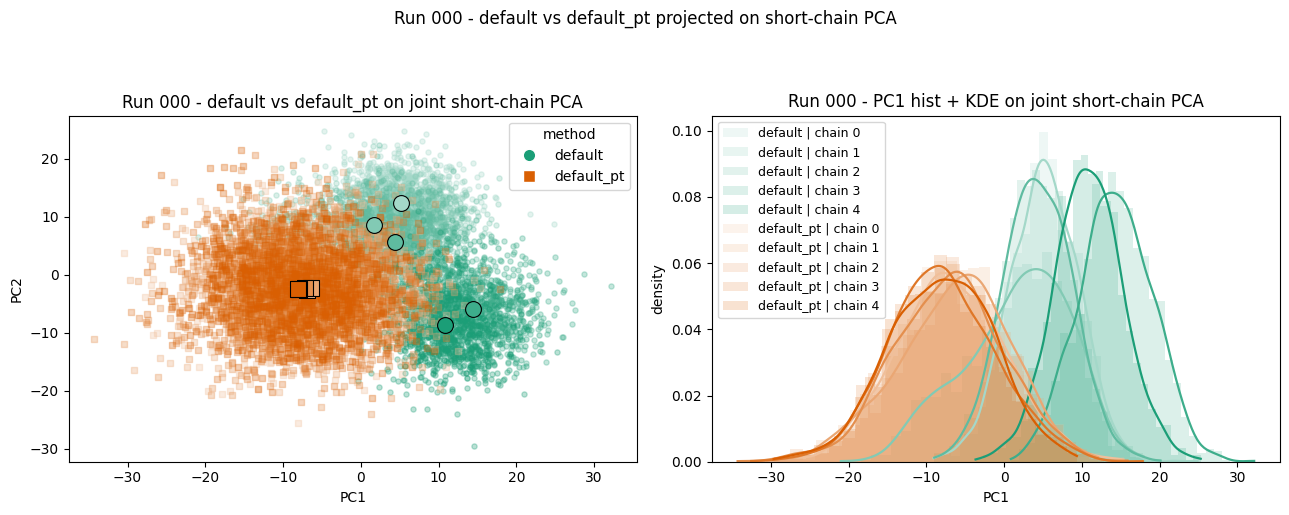

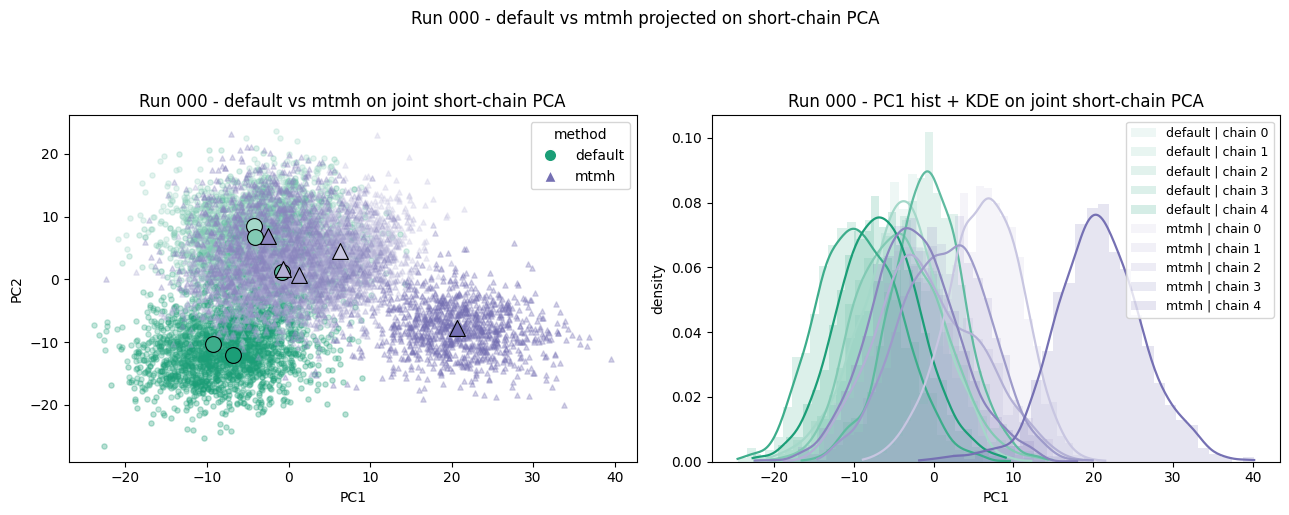

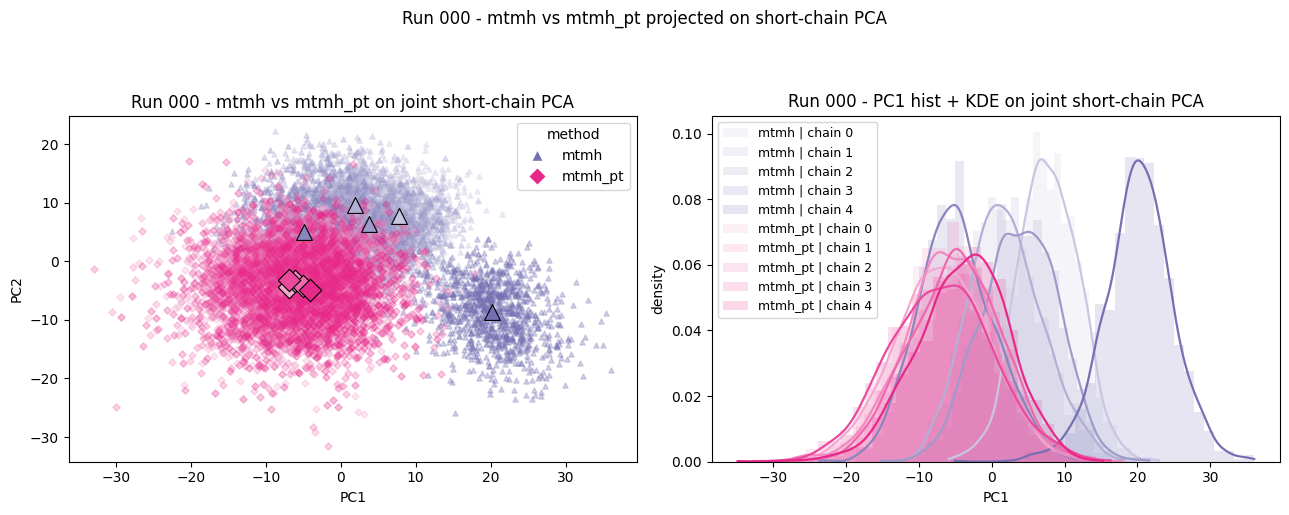

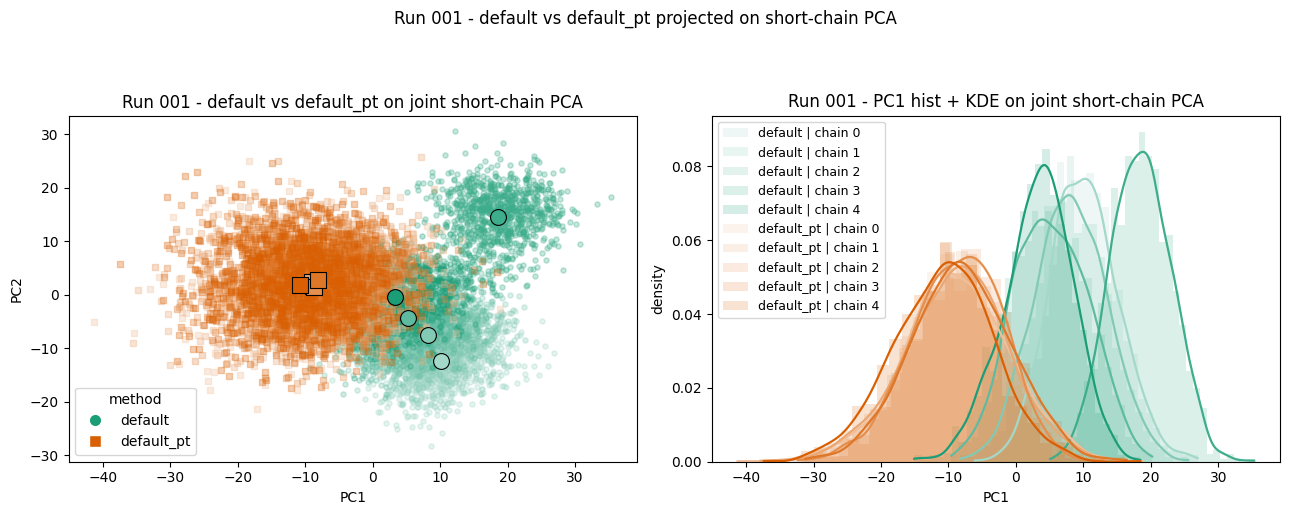

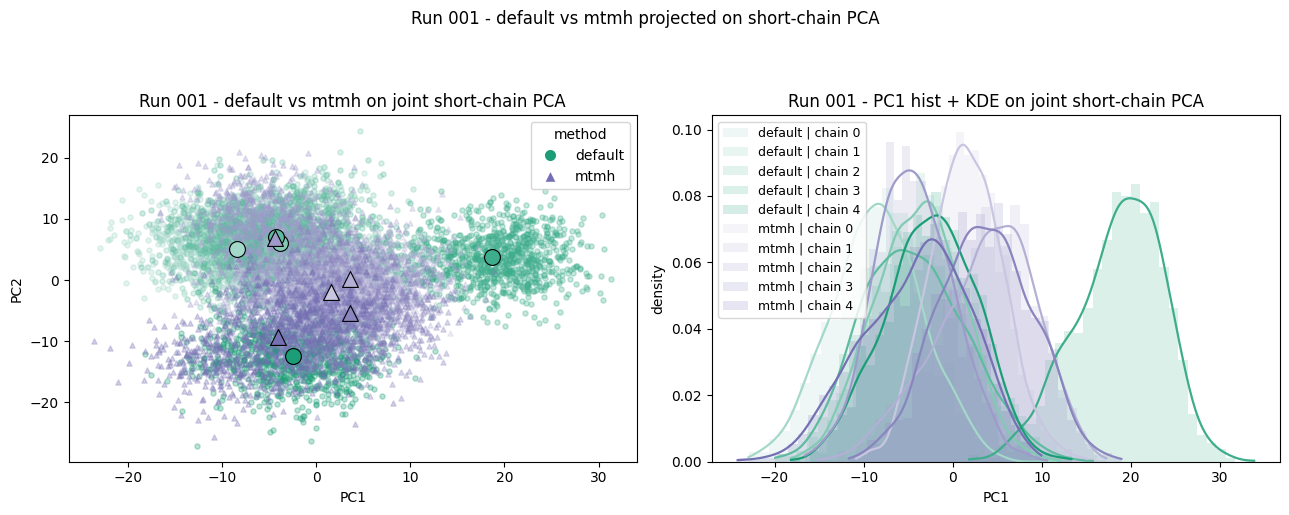

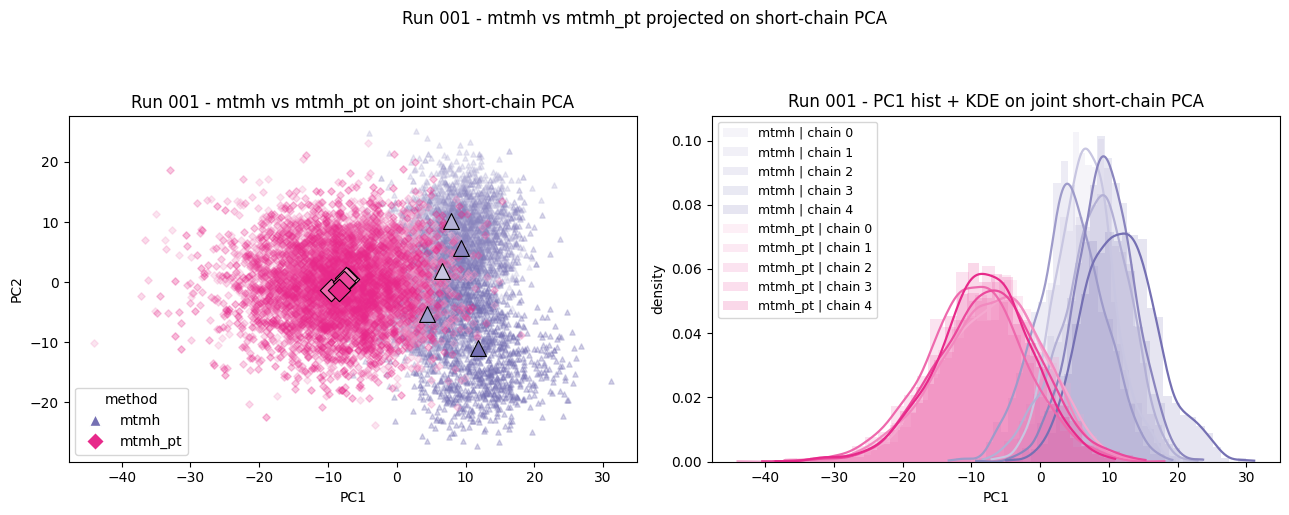

In [6]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

PT_STORE = ROOT / "diagnosis" / "pt+mtmh_2000" / "store"
RUN_IDS = [0, 1]  # update if you have more runs
PAIRWISE_COMPARISONS = [
    ("default", "default_pt"),
    ("default", "mtmh"),
    ("mtmh", "mtmh_pt"),
]
BURN_IN = 500
DOWNSAMPLE_PER_CHAIN = 1000
SCATTER_ALPHA = 0.30
METHOD_MARKERS = {
    "default": "o",
    "default_pt": "s",
    "mtmh": "^",
    "mtmh_pt": "D",
}
METHOD_COLORS = {
    "default": "#1b9e77",
    "default_pt": "#d95f02",
    "mtmh": "#7570b3",
    "mtmh_pt": "#e7298a",
}

def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape

def _load_pred_chains(run_id: int, method: str):
    preds_path = PT_STORE / "preds" / f"{notebook}_pt_mtmh__run{run_id:03d}__{method}__preds.csv"
    preds_raw, preds_shape = _load_with_shape(preds_path)
    preds = preds_raw.reshape(preds_shape)
    chains = []
    for chain_id in range(preds.shape[0]):
        chain_preds = preds[chain_id]
        if BURN_IN > 0:
            chain_preds = chain_preds[:, BURN_IN:]
        chains.append(chain_preds)
    return preds, chains

def _fit_joint_short_pca(run_id: int, method_a: str, method_b: str):
    _, method_a_chains = _load_pred_chains(run_id, method_a)
    _, method_b_chains = _load_pred_chains(run_id, method_b)
    joint_blocks = [chain_preds.T for chain_preds in method_a_chains + method_b_chains]
    joint_predictions = np.vstack(joint_blocks)
    pca = PCA(n_components=2, random_state=0)
    pca.fit(joint_predictions)
    return pca, {method_a: method_a_chains, method_b: method_b_chains}

def _method_chain_shades(base_hex, n):
    base = np.array(mcolors.to_rgb(base_hex))
    if n == 1:
        return [tuple(base)]
    shades = []
    for i in range(n):
        t = 0.4 + 0.6 * (i / max(1, n - 1))
        rgb = tuple(base * t + (1 - t) * np.array([1.0, 1.0, 1.0]))
        shades.append(rgb)
    return shades

def _plot_pc1_hist_kde(ax, items, title):
    for label, color, data in items:
        data = np.asarray(data)
        ax.hist(data, bins=30, density=True, alpha=0.18, color=color, label=label)
        try:
            kde = gaussian_kde(data)
            xs = np.linspace(np.min(data), np.max(data), 200)
            ax.plot(xs, kde(xs), color=color, linewidth=1.6)
        except Exception:
            pass

    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('density')
    ax.legend(fontsize=9)

def _scatter_method_chains(ax, pca, method_chains, method_name, title):
    marker = METHOD_MARKERS.get(method_name, 'o')
    base_color = METHOD_COLORS.get(method_name, '#333333')
    n_chains = len(method_chains)
    shades = _method_chain_shades(base_color, n_chains)
    rng = np.random.default_rng(0)

    for chain_id, chain_preds in enumerate(method_chains):
        chain_color = shades[chain_id % len(shades)]
        coords = pca.transform(chain_preds.T)
        if DOWNSAMPLE_PER_CHAIN is not None and DOWNSAMPLE_PER_CHAIN < coords.shape[0]:
            idx = rng.choice(coords.shape[0], size=DOWNSAMPLE_PER_CHAIN, replace=False)
        else:
            idx = np.arange(coords.shape[0])
        ax.scatter(coords[idx, 0], coords[idx, 1], marker=marker, s=14, alpha=SCATTER_ALPHA, color=chain_color, label='_nolegend_')
        centroid = np.mean(coords, axis=0)
        ax.scatter(centroid[0], centroid[1], marker=marker, s=130, color=chain_color, edgecolor='black', linewidth=0.8, label=f'{method_name} | chain {chain_id}', zorder=5)

    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

for run_id in RUN_IDS:
    for method_a, method_b in PAIRWISE_COMPARISONS:
        joint_pca, method_groups = _fit_joint_short_pca(run_id, method_a, method_b)

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        for method_name, method_chains in method_groups.items():
            _scatter_method_chains(axes[0], joint_pca, method_chains, method_name, title=f'Run {run_id:03d} - {method_a} vs {method_b} on joint short-chain PCA')

        legend_handles = [Line2D([0], [0], marker=METHOD_MARKERS[m], color='w', markerfacecolor=METHOD_COLORS[m], markersize=9, label=m) for m in method_groups.keys()]
        axes[0].legend(handles=legend_handles, title='method')

        items = []
        for method_name, method_chains in method_groups.items():
            base_color = METHOD_COLORS.get(method_name, '#333333')
            shades = _method_chain_shades(base_color, len(method_chains))
            for cidx, chain_preds in enumerate(method_chains):
                pc1 = joint_pca.transform(chain_preds.T)[:, 0]
                items.append((f'{method_name} | chain {cidx}', shades[cidx % len(shades)], pc1))

        _plot_pc1_hist_kde(axes[1], items, title=f'Run {run_id:03d} - PC1 hist + KDE on joint short-chain PCA')

        fig.suptitle(f'Run {run_id:03d} - {method_a} vs {method_b} projected on short-chain PCA', y=1.02)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


In [7]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

LONG_STORE = ROOT / "diagnosis" / "1M-iters" / "store"
SHORT_STORE = ROOT / "diagnosis" / "pt+mtmh_2000" / "store"
LONG_TAG = notebook
SHORT_TAG = f"{notebook}_pt_mtmh"
LONG_METHOD = "default"
SHORT_METHODS = ["default", "default_pt", "mtmh", "mtmh_pt"]
LONG_BURN_IN = 0
SHORT_BURN_IN = 500
METHOD_LABELS = {
    "default": "Default (2k)",
    "default_pt": "Default PT (2k)",
    "mtmh": "MTMH (2k)",
    "mtmh_pt": "MTMH + PT (2k)",
    "long_default": "Default (1M)",
}


def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape


def _crps_from_samples(samples, y_true):
    samples = np.asarray(samples)
    y_true = np.asarray(y_true)
    n_points, n_samples = samples.shape
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)
    samples_sorted = np.sort(samples, axis=1)
    k = np.arange(1, n_samples + 1)
    coeffs = (2 * k - n_samples - 1)[None, :]
    term2 = np.sum(coeffs * samples_sorted, axis=1) / (n_samples**2)
    return term1 - term2


def _load_prediction_chains(store_root: Path, tag: str, run_id: int, method: str, burn_in: int):
    preds_path = store_root / "preds" / f"{tag}__run{run_id:03d}__{method}__preds.csv"
    preds_raw, preds_shape = _load_with_shape(preds_path)
    preds = preds_raw.reshape(preds_shape)
    chains = []
    for chain_id in range(preds.shape[0]):
        chain_preds = preds[chain_id]
        if burn_in > 0:
            chain_preds = chain_preds[:, burn_in:]
        chains.append(chain_preds)
    return preds, chains


def _load_subsample_y(store_root: Path, tag: Path, run_id: int):
    y_path = store_root / "subsample_y_test" / f"{tag}__run{run_id:03d}__subsample_y_test.csv"
    y_raw, y_shape = _load_with_shape(y_path)
    return np.asarray(y_raw.reshape(y_shape)).reshape(-1)


def _available_run_ids(store_root: Path, tag: str, method: str):
    preds_dir = store_root / "preds"
    run_ids = []
    for path in preds_dir.glob(f"{tag}__run*__{method}__preds.csv"):
        parts = path.name.split("__run")
        if len(parts) < 2:
            continue
        run_fragment = parts[1].split("__", 1)[0]
        try:
            run_ids.append(int(run_fragment))
        except ValueError:
            continue
    return sorted(set(run_ids))


def _chain_metric_row(chain_preds, y_true):
    y_pred = np.mean(chain_preds, axis=1)
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    crps = float(np.mean(_crps_from_samples(chain_preds, y_true)))
    return rmse, crps


run_ids = sorted(
    set(_available_run_ids(LONG_STORE, LONG_TAG, LONG_METHOD))
    & set(_available_run_ids(SHORT_STORE, SHORT_TAG, "default"))
    & set(_available_run_ids(SHORT_STORE, SHORT_TAG, "default_pt"))
    & set(_available_run_ids(SHORT_STORE, SHORT_TAG, "mtmh"))
    & set(_available_run_ids(SHORT_STORE, SHORT_TAG, "mtmh_pt"))
)
if not run_ids:
    run_ids = RUN_IDS

rmse_rows = []
crps_rows = []

for run_id in run_ids:
    y_true = _load_subsample_y(LONG_STORE, LONG_TAG, run_id)
    short_y = _load_subsample_y(SHORT_STORE, SHORT_TAG, run_id)
    if y_true.shape != short_y.shape or not np.allclose(y_true, short_y):
        raise ValueError(
            f"Run {run_id:03d} uses different subsample_y_test values between long and short stores; "
            "the comparison table expects matched test points."
        )

    rmse_row = {"run": f"Run {run_id:03d}"}
    crps_row = {"run": f"Run {run_id:03d}"}

    _, long_chains = _load_prediction_chains(LONG_STORE, LONG_TAG, run_id, LONG_METHOD, LONG_BURN_IN)
    long_rmse_vals = []
    long_crps_vals = []
    for chain_preds in long_chains:
        rmse_val, crps_val = _chain_metric_row(chain_preds, y_true)
        long_rmse_vals.append(rmse_val)
        long_crps_vals.append(crps_val)
    rmse_row[METHOD_LABELS["long_default"]] = float(np.mean(long_rmse_vals))
    crps_row[METHOD_LABELS["long_default"]] = float(np.mean(long_crps_vals))

    for method in SHORT_METHODS:
        _, short_chains = _load_prediction_chains(SHORT_STORE, SHORT_TAG, run_id, method, SHORT_BURN_IN)
        rmse_vals = []
        crps_vals = []
        for chain_preds in short_chains:
            rmse_val, crps_val = _chain_metric_row(chain_preds, y_true)
            rmse_vals.append(rmse_val)
            crps_vals.append(crps_val)
        rmse_row[METHOD_LABELS[method]] = float(np.mean(rmse_vals))
        crps_row[METHOD_LABELS[method]] = float(np.mean(crps_vals))

    rmse_rows.append(rmse_row)
    crps_rows.append(crps_row)

rmse_df = pd.DataFrame(rmse_rows).set_index("run")
crps_df = pd.DataFrame(crps_rows).set_index("run")

column_order = [
    METHOD_LABELS["default"],
    METHOD_LABELS["default_pt"],
    METHOD_LABELS["mtmh"],
    METHOD_LABELS["mtmh_pt"],
    METHOD_LABELS["long_default"],
]
rmse_df = rmse_df[column_order]
crps_df = crps_df[column_order]

print("RMSE")
display(rmse_df.round(4))
print("\nCRPS")
display(crps_df.round(4))


RMSE


,Default (2k),Default PT (2k),MTMH (2k),MTMH + PT (2k),Default (1M)
run,,,,,
Run 000,4.9841,5.0597,4.5863,4.9297,4.2558
Run 001,5.0731,4.7469,5.0376,4.6892,4.7747



CRPS


,Default (2k),Default PT (2k),MTMH (2k),MTMH + PT (2k),Default (1M)
run,,,,,
Run 000,2.6878,2.7899,2.4566,2.7017,2.2666
Run 001,2.6018,2.5526,2.6014,2.4708,2.3731
